In [1]:
# %%
# Step 1: Import Libraries and Set Seeds
# --------------------------------------
import os
os.environ['PYTHONHASHSEED'] = '42'

import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Conv1D, MaxPooling1D, Flatten, Dropout
import keras_tuner as kt
import joblib

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# Set FULL_DETERMINISM=1 to also enforce bit-for-bit op determinism.
# This adds a large runtime cost (often 5-10x slower for RNN training)
# and is rarely needed for paper-grade reproducibility, since
# `set_random_seed` already pins all the random initialisers, dropout,
# and tuner sampling. Off by default; flip on for camera-ready runs.
if os.environ.get('FULL_DETERMINISM') == '1':
    try:
        tf.config.experimental.enable_op_determinism()
    except Exception as exc:
        print(f"Warning: could not enable full op determinism: {exc}")


2026-05-03 17:32:54.458980: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# %%
# Step 2: Load and Preprocess Data
# --------------------------------
file_path = 'BNBL_price_report_All.csv'
df = pd.read_csv(file_path)

df['Date'] = pd.to_datetime(df['Date'])
df_daily = df.groupby(df['Date'].dt.date)['Close Price'].last().reset_index()
df_daily.rename(columns={'Date':'Date','Close Price':'Close'}, inplace=True)
df_daily['Date'] = pd.to_datetime(df_daily['Date'])
df_daily.set_index('Date', inplace=True)
print(f"Daily series: {df_daily.index.min().date()} -> {df_daily.index.max().date()}  ({len(df_daily)} obs)")
df_daily.tail()


Daily series: 2020-04-23 -> 2025-10-01  (1338 obs)


,Close
Date,
2025-09-25,31.02
2025-09-26,31.23
2025-09-29,31.50
2025-09-30,31.40
2025-10-01,31.40


In [3]:
# Step 3: Time-ordered Train / Val / Test Split
# ---------------------------------------------
test_size = 30
val_size = 60
# seq_length = 60 (~3 trading months); chosen as a window long enough to capture
# weekly-to-monthly autocorrelation while leaving sufficient training sequences.
seq_length = 60
data = df_daily['Close'].values.reshape(-1, 1)

train_end = len(data) - (val_size + test_size)
val_end = len(data) - test_size

train_data = data[:train_end]
val_data = data[train_end - seq_length:val_end]   # overlap seq_length for continuity
test_data = data[val_end - seq_length:]           # overlap seq_length for continuity

print(f"Train samples: {len(train_data)}, Val samples: {len(val_data)}, Test samples: {len(test_data)}")
print(f"Train range: {df_daily.index[0].date()} -> {df_daily.index[train_end - 1].date()}")
print(f"Val   range: {df_daily.index[train_end].date()} -> {df_daily.index[val_end - 1].date()}")
print(f"Test  range: {df_daily.index[val_end].date()} -> {df_daily.index[-1].date()}")


Train samples: 1248, Val samples: 120, Test samples: 90
Train range: 2020-04-23 -> 2025-05-23
Val   range: 2025-05-26 -> 2025-08-19
Test  range: 2025-08-20 -> 2025-10-01


In [4]:
# Step 4: Scale Data Without Leakage
# ----------------------------------
scaler = MinMaxScaler()
scaler.fit(train_data)               # Fit ONLY on training data

train_scaled = scaler.transform(train_data)
val_scaled = scaler.transform(val_data)
test_scaled = scaler.transform(test_data)




In [5]:
# Step 5: Create Sequences for Each Split
# ---------------------------------------
def create_sequences(data, seq_length=60):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i - seq_length:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, seq_length)
X_val, y_val = create_sequences(val_scaled, seq_length)
X_test, y_test = create_sequences(test_scaled, seq_length)

# Reshape to [samples, timesteps, features]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print(f"Train: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")

Train: (1188, 60, 1), Validation: (60, 60, 1), Test: (30, 60, 1)


In [6]:
# %%
# Step 6: Directional Accuracy (anchored on yesterday's ACTUAL price)
# ------------------------------------------------------------------
def directional_accuracy(y_true, y_pred, prev_actual, tol=1e-9):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    prev_actual = np.asarray(prev_actual, dtype=float)
    actual_move = y_true - prev_actual
    pred_move = y_pred - prev_actual
    mask = np.abs(actual_move) > tol
    if mask.sum() == 0:
        return float('nan')
    return np.mean(np.sign(actual_move[mask]) == np.sign(pred_move[mask])) * 100


In [7]:
# %%
# Step 7: Build Hypermodels (LSTM, GRU, CNN, CNN+LSTM)
# -----------------------------------------------------
def build_lstm_model(hp):
    model = Sequential()
    num_layers = hp.Int('num_layers', 1, 3)
    for i in range(num_layers):
        units = hp.Int(f'units_{i}', 32, 128, step=16)
        return_seq = i < num_layers - 1
        if i == 0:
            model.add(LSTM(units, return_sequences=return_seq, input_shape=(X_train.shape[1],1)))
        else:
            model.add(LSTM(units, return_sequences=return_seq))
        model.add(Dropout(hp.Float(f'dropout_{i}', 0.0, 0.5, step=0.1)))
    model.add(Dense(1))
    model.compile(
        optimizer=tf.keras.optimizers.Adam(hp.Float('lr',1e-4,1e-2,sampling='log')),
        loss='mse'
    )
    return model

def build_gru_model(hp):
    model = Sequential()
    num_layers = hp.Int('num_layers', 1, 3)
    for i in range(num_layers):
        units = hp.Int(f'units_{i}', 32, 128, step=16)
        return_seq = i < num_layers - 1
        if i == 0:
            model.add(GRU(units, return_sequences=return_seq, input_shape=(X_train.shape[1],1)))
        else:
            model.add(GRU(units, return_sequences=return_seq))
        model.add(Dropout(hp.Float(f'dropout_{i}', 0.0, 0.5, step=0.1)))
    model.add(Dense(1))
    model.compile(
        optimizer=tf.keras.optimizers.Adam(hp.Float('lr',1e-4,1e-2,sampling='log')),
        loss='mse'
    )
    return model

def build_cnn_model(hp):
    model = Sequential([
        Conv1D(filters=hp.Int('filters',32,128,step=16), 
               kernel_size=hp.Choice('kernel', [2,3,5]), 
               activation='relu', 
               input_shape=(X_train.shape[1],1)),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(hp.Int('dense_units',32,128,step=16), activation='relu'),
        Dense(1)
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(hp.Float('lr',1e-4,1e-2,sampling='log')),
        loss='mse'
    )
    return model

def build_cnn_lstm_model(hp):
    model = Sequential([
        Conv1D(filters=hp.Int('filters',32,128,step=16), 
               kernel_size=hp.Choice('kernel',[2,3,5]), 
               activation='relu', 
               input_shape=(X_train.shape[1],1)),
        MaxPooling1D(pool_size=2),
        LSTM(hp.Int('units',32,128,step=16)),
        Dense(1)
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(hp.Float('lr',1e-4,1e-2,sampling='log')),
        loss='mse'
    )
    return model



In [8]:
# %%
# Step 8: Hyperparameter Tuning and Model Training
# ------------------------------------------------
def tune_and_train(name, build_fn, X_train, y_train, X_val, y_val,
                   max_trials=5, epochs=50, seed=SEED):
    """Tune with KerasTuner per-architecture, then retrain best HP on the
    full training set with early stopping. Each architecture gets its own
    project directory so trials never leak between models. The
    ModelCheckpoint callback was removed because it has been observed to
    trigger an internal TensorFlow assertion
    ('counter.h: Check failed: 0 <= step ... Must not decrement
    cumulative metrics') that kills the kernel; Step 10 saves every
    model afterwards so the per-trial checkpoint was redundant anyway.
    """
    tuner = kt.RandomSearch(
        build_fn,
        objective='val_loss',
        max_trials=max_trials,
        executions_per_trial=1,
        directory='tuner_dir',
        project_name=f'stock_{name}',
        overwrite=True,
        seed=seed,
    )

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    )

    tuner.search(
        X_train, y_train, validation_data=(X_val, y_val),
        epochs=epochs, callbacks=[early_stop], verbose=1,
    )

    best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
    print(f"[{name}] best HP: {best_hp.values}")
    model = build_fn(best_hp)
    model.fit(
        X_train, y_train, validation_data=(X_val, y_val),
        epochs=epochs, callbacks=[early_stop], verbose=1,
    )
    return model


In [9]:
# %%
# Step 9: Train All Models
# ------------------------
trained_models = {}
predictions = {}

models = {
    'LSTM': build_lstm_model,
    'GRU': build_gru_model,
    'CNN': build_cnn_model,
    'CNN_LSTM': build_cnn_lstm_model,
}

for name, build_fn in models.items():
    print(f"Tuning & training {name}...")
    model = tune_and_train(name, build_fn, X_train, y_train, X_val, y_val)
    trained_models[name] = model

    pred = model.predict(X_test)
    pred = scaler.inverse_transform(pred).flatten()
    predictions[name] = pred


Trial 5 Complete [00h 01m 01s]
val_loss: 0.0003280252276454121

Best val_loss So Far: 0.00031814913381822407
Total elapsed time: 00h 06m 46s
[CNN_LSTM] best HP: {'filters': 96, 'kernel': 2, 'units': 64, 'lr': 0.0003497444477863496}
Epoch 1/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - loss: 0.0326 - val_loss: 0.0019
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0080 - val_loss: 0.0026
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0073 - val_loss: 0.0020
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0066 - val_loss: 0.0016
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0062 - val_loss: 0.0014
Epoch 6/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0057 - val_loss: 0.0012
Epoch 7/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0054 - val_loss: 0.0010
Epoch 8/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.0050 - val_loss: 9.4054e-04
Epoch 9/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.0047 - val_loss: 8.7182

In [10]:
# %%
# Step 10: Save Models and Scaler
# --------------------------------
os.makedirs('models', exist_ok=True)
for name, model in trained_models.items():
    model.save(f'models/{name}_model.keras')

joblib.dump(scaler, 'models/scaler.joblib')


['models/scaler.joblib']

In [11]:
# %%
# Step 11: Evaluate Models
# ------------------------
actual_prices = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Anchor for DA: actual close on the day BEFORE each test prediction.
# y_test[0] corresponds to df_daily.iloc[val_end]; the previous trading
# day is df_daily.iloc[val_end - 1].
prev_actual_for_test = np.concatenate([
    [df_daily['Close'].iloc[val_end - 1]],
    actual_prices[:-1],
])

print(f"{'Model':<10} {'MAE':>8} {'RMSE':>8} {'DA(%)':>8}")
for name, pred in predictions.items():
    mae = mean_absolute_error(actual_prices, pred)
    rmse = np.sqrt(mean_squared_error(actual_prices, pred))
    da = directional_accuracy(actual_prices, pred, prev_actual_for_test)
    print(f"{name:<10} {mae:>8.4f} {rmse:>8.4f} {da:>8.2f}")


Model           MAE     RMSE    DA(%)
LSTM         0.1434   0.2229    14.29
GRU          0.1028   0.1702    14.29
CNN          0.1145   0.1629    57.14
CNN_LSTM     0.1412   0.2237    14.29


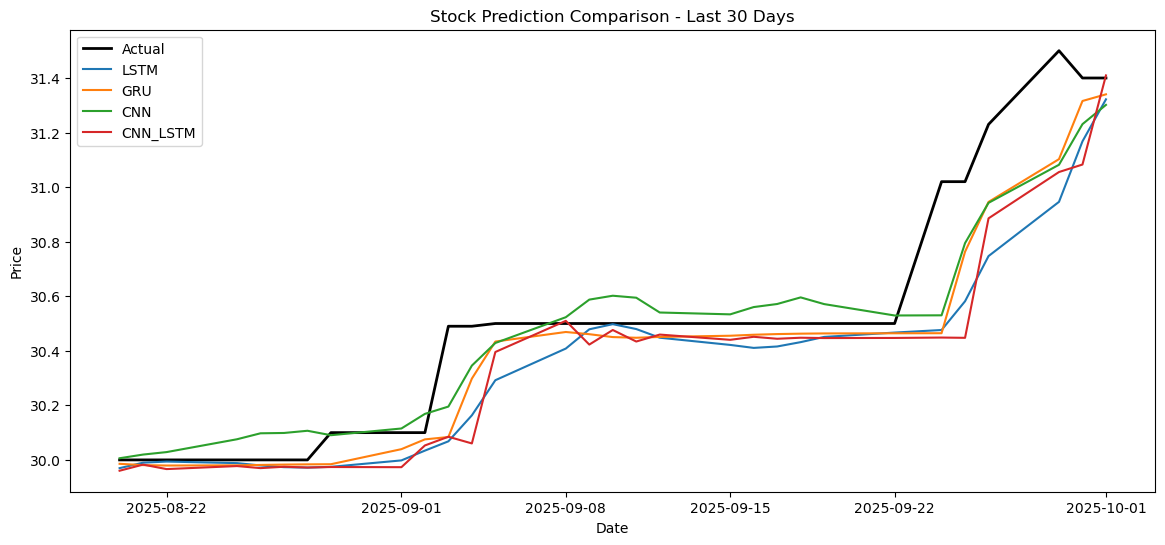

In [12]:
# %%
# Step 12: Comparison Table & Plot
# ---------------------------------
df_compare = pd.DataFrame({'Date': df_daily.index[-test_size:], 'Actual': actual_prices})
for name in predictions:
    df_compare[name] = predictions[name]
df_compare.set_index('Date', inplace=True)

plt.figure(figsize=(14,6))
plt.plot(df_compare['Actual'], label='Actual', color='black', linewidth=2)
for name in predictions:
    plt.plot(df_compare[name], label=name)
plt.title('Stock Prediction Comparison - Last 30 Days')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.show()

In [13]:
# %%
# Step 13: Display Table of Actual vs Predicted Prices (Last 30 Days)
# -------------------------------------------------------------------
import IPython.display as display

# Reset index for nicer display
df_table = df_compare.reset_index()
df_table.rename(columns={'index':'Date'}, inplace=True)

# Display the table
display.display(df_table)

# Optional: save table to CSV
df_table.to_csv('models/last_30_days_predictions.csv', index=False)


,Date,Actual,LSTM,GRU,CNN,CNN_LSTM
0,2025-08-20,30.00,29.969793,29.985647,30.006117,29.960358
1,2025-08-21,30.00,29.989784,29.980906,30.019602,29.982723
2,2025-08-22,30.00,29.993919,29.979395,30.028652,29.966358
3,2025-08-25,30.00,29.988195,29.980150,30.075705,29.977419
4,2025-08-26,30.00,29.979643,29.981583,30.097559,29.969885
5,2025-08-27,30.00,29.973444,29.982843,30.098742,29.974913
6,2025-08-28,30.00,29.971867,29.983713,30.106821,29.972015
7,2025-08-29,30.10,29.974621,29.984249,30.090553,29.973923
8,2025-09-01,30.10,29.998169,30.039421,30.115179,29.973345
9,2025-09-02,30.10,30.034054,30.075256,30.168715,30.052950


In [14]:
# %%
# Step 14: Rolling-origin (expanding-window) backtest
# ---------------------------------------------------
# Evaluate LSTM, GRU, CNN and CNN-LSTM on K non-overlapping
# expanding-window test slices of length H. We use FIXED architectures
# (not KerasTuner-tuned) inside the multi-window loop because re-tuning
# K x 4 = 24 architectures with RandomSearch would take many hours and
# is not necessary for assessing across-window robustness. The single-
# window tuned results above remain the reference for the main analysis;
# the multi-window numbers below quantify how stable the relative
# rankings are when the test period changes.

K_BT = 6      # number of test windows
H_BT = 30     # length of each test window in days
SEQ_BT = 60   # sequence length, matches Step 3
VAL_BT = 60   # validation set size, matches Step 3

def _build_lstm():
    m = Sequential([
        LSTM(64, return_sequences=True, input_shape=(SEQ_BT, 1)),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(1),
    ])
    m.compile(optimizer="adam", loss="mse")
    return m

def _build_gru():
    m = Sequential([
        GRU(64, return_sequences=True, input_shape=(SEQ_BT, 1)),
        Dropout(0.2),
        GRU(32),
        Dropout(0.2),
        Dense(1),
    ])
    m.compile(optimizer="adam", loss="mse")
    return m

def _build_cnn():
    m = Sequential([
        Conv1D(64, kernel_size=3, activation="relu", input_shape=(SEQ_BT, 1)),
        MaxPooling1D(2),
        Flatten(),
        Dense(64, activation="relu"),
        Dense(1),
    ])
    m.compile(optimizer="adam", loss="mse")
    return m

def _build_cnn_lstm():
    m = Sequential([
        Conv1D(64, kernel_size=3, activation="relu", input_shape=(SEQ_BT, 1)),
        MaxPooling1D(2),
        LSTM(64),
        Dense(1),
    ])
    m.compile(optimizer="adam", loss="mse")
    return m

_BUILDERS_BT = {
    "LSTM": _build_lstm,
    "GRU": _build_gru,
    "CNN": _build_cnn,
    "CNN_LSTM": _build_cnn_lstm,
}

def _da_anchored_bt(y_true, y_pred, prev_actual):
    actual_move = np.asarray(y_true) - np.asarray(prev_actual)
    pred_move = np.asarray(y_pred) - np.asarray(prev_actual)
    mask = np.abs(actual_move) > 1e-9
    if mask.sum() == 0:
        return float("nan")
    return float(np.mean(np.sign(actual_move[mask]) == np.sign(pred_move[mask])) * 100)

def _create_seq_bt(scaled, seq=SEQ_BT):
    X, y = [], []
    for i in range(seq, len(scaled)):
        X.append(scaled[i - seq:i, 0])
        y.append(scaled[i, 0])
    return np.array(X).reshape(-1, seq, 1), np.array(y)

def _run_dl_window(daily, test_start, test_end):
    series_arr = daily["Close"].astype(float).values.reshape(-1, 1)
    val_start = test_start - VAL_BT
    train_data = series_arr[:val_start]
    val_data = series_arr[val_start - SEQ_BT:test_start]
    test_data = series_arr[test_start - SEQ_BT:test_end]

    sc = MinMaxScaler()
    sc.fit(train_data)
    tr = sc.transform(train_data); va = sc.transform(val_data); te = sc.transform(test_data)
    X_tr, y_tr = _create_seq_bt(tr); X_va, y_va = _create_seq_bt(va); X_te, y_te = _create_seq_bt(te)

    actual_prices = sc.inverse_transform(y_te.reshape(-1, 1)).flatten()
    prev_actual = np.concatenate(
        [[float(daily["Close"].iloc[test_start - 1])], actual_prices[:-1]]
    )
    es = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)

    out = {}
    for name, build in _BUILDERS_BT.items():
        tf.keras.utils.set_random_seed(SEED)
        m = build()
        m.fit(X_tr, y_tr, validation_data=(X_va, y_va),
              epochs=60, batch_size=32, callbacks=[es], verbose=0)
        pred = sc.inverse_transform(m.predict(X_te, verbose=0)).flatten()
        y = actual_prices.astype(float); nz = y != 0
        out[name] = {
            "MAE": float(mean_absolute_error(y, pred)),
            "RMSE": float(np.sqrt(mean_squared_error(y, pred))),
            "MAPE": float(np.mean(np.abs((y[nz] - pred[nz]) / y[nz])) * 100),
            "DA":   _da_anchored_bt(y, pred, prev_actual),
        }
        tf.keras.backend.clear_session()
    return out

n_bt = len(df_daily)
windows_bt, end_bt = [], n_bt
for _ in range(K_BT):
    start_bt = end_bt - H_BT
    if start_bt - SEQ_BT - VAL_BT < 30:
        break
    windows_bt.append((start_bt, end_bt))
    end_bt = start_bt
windows_bt = list(reversed(windows_bt))

per_window_dl = []
for wi, (a, b) in enumerate(windows_bt, start=1):
    print(f"--- DL window {wi}/{len(windows_bt)}: {df_daily.index[a].date()} -> {df_daily.index[b-1].date()} ---", flush=True)
    res = _run_dl_window(df_daily, a, b)
    for name, m in res.items():
        per_window_dl.append((name, wi, m["MAE"], m["RMSE"], m["MAPE"], m["DA"]))
        print(f"  {name:<10} MAE={m['MAE']:.4f} RMSE={m['RMSE']:.4f} MAPE={m['MAPE']:.2f}% DA={m['DA']:.2f}%", flush=True)

dl_per_window_df = pd.DataFrame(
    per_window_dl, columns=["model", "window", "MAE", "RMSE", "MAPE", "DA"]
)
dl_agg_df = dl_per_window_df.groupby("model").agg(
    MAE_mean=("MAE", "mean"), MAE_std=("MAE", "std"),
    RMSE_mean=("RMSE", "mean"), RMSE_std=("RMSE", "std"),
    MAPE_mean=("MAPE", "mean"), MAPE_std=("MAPE", "std"),
    DA_mean=("DA", "mean"), DA_std=("DA", "std"),
).round(4)
print("\nDL per-window results:")
print(dl_per_window_df.to_string(index=False))
print("\nDL mean ± std across windows:")
print(dl_agg_df.to_string())


--- DL window 1/6: 2025-01-13 -> 2025-02-25 ---


/Users/ugyen/anaconda3/envs/stock-forecast/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


/Users/ugyen/anaconda3/envs/stock-forecast/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


/Users/ugyen/anaconda3/envs/stock-forecast/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/ugyen/anaconda3/envs/stock-forecast/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  LSTM       MAE=0.0556 RMSE=0.1112 MAPE=0.18% DA=50.00%
  GRU        MAE=0.1599 RMSE=0.1650 MAPE=0.53% DA=75.00%
  CNN        MAE=0.1679 RMSE=0.2078 MAPE=0.56% DA=50.00%
  CNN_LSTM   MAE=0.1173 RMSE=0.1534 MAPE=0.39% DA=50.00%
--- DL window 2/6: 2025-02-26 -> 2025-04-09 ---


...

  LSTM       MAE=0.0225 RMSE=0.0381 MAPE=0.07% DA=75.00%
  GRU        MAE=0.0827 RMSE=0.0922 MAPE=0.26% DA=50.00%
  CNN        MAE=0.0685 RMSE=0.0866 MAPE=0.22% DA=100.00%
  CNN_LSTM   MAE=0.4006 RMSE=0.4125 MAPE=1.28% DA=50.00%
--- DL window 5/6: 2025-07-08 -> 2025-08-19 ---


/Users/ugyen/anaconda3/envs/stock-forecast/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/Users/ugyen/anaconda3/envs/stock-forecast/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/Users/ugyen/anaconda3/envs/stock-forecast/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularize

  LSTM       MAE=0.1833 RMSE=0.2867 MAPE=0.61% DA=25.00%
  GRU        MAE=0.5748 RMSE=0.6164 MAPE=1.91% DA=25.00%
  CNN        MAE=0.1179 RMSE=0.2034 MAPE=0.39% DA=75.00%
  CNN_LSTM   MAE=0.8014 RMSE=0.8452 MAPE=2.66% DA=25.00%
--- DL window 6/6: 2025-08-20 -> 2025-10-01 ---


/Users/ugyen/anaconda3/envs/stock-forecast/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/Users/ugyen/anaconda3/envs/stock-forecast/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/Users/ugyen/anaconda3/envs/stock-forecast/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularize

  LSTM       MAE=0.1223 RMSE=0.1931 MAPE=0.40% DA=14.29%
  GRU        MAE=0.5130 RMSE=0.5650 MAPE=1.69% DA=100.00%
  CNN        MAE=0.2923 RMSE=0.3837 MAPE=0.95% DA=42.86%
  CNN_LSTM   MAE=0.3792 RMSE=0.4209 MAPE=1.25% DA=71.43%

DL per-window results:
   model  window      MAE     RMSE     MAPE         DA
    LSTM       1 0.055610 0.111219 0.184173  50.000000
     GRU       1 0.159890 0.164957 0.531982  75.000000
     CNN       1 0.167917 0.207825 0.558183  50.000000
CNN_LSTM       1 0.117250 0.153389 0.389412  50.000000
    LSTM       2 0.034198 0.056396 0.113603  66.666667
     GRU       2 0.361666 0.370233 1.202390  33.333333
     CNN       2 0.357317 0.375165 1.185973  66.666667
CNN_LSTM       2 0.047310 0.057496 0.157066  66.666667
    LSTM       3 0.405385 0.636930 1.311582  25.000000
     GRU       3 0.212037 0.450569 0.688678  25.000000
     CNN       3 0.832030 0.924047 2.690648  25.000000
CNN_LSTM       3 0.729481 0.821747 2.406367  50.000000
    LSTM       4 0.022524 0.0381